In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from matplotlib import pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from utilz.Dataset import load_dataset
from utilz.constans import DISEASE, HEALTHY
meta_path = r"../data/samples_pancreatic.xlsx"
data_path = r"../data/counts_pancreatic.csv"
ds = load_dataset(data_path, meta_path, label_col="Group")

TEST_SIZE = 0.2
VALID_SIZE = 0.2
ANOVA_PERCENTILE = 60
MEAN_PERCENTILE = 20

ds.y = ds.y.replace({DISEASE: HEALTHY})

le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(ds.y), index=ds.y.index)
X_train, X_test, y_train, y_test = (
    ds.get_train_test_valid_split(ds.X, y_encoded, test_size=TEST_SIZE, return_valid = False)
)

print("test set size:", len(X_test))
print("train set size:", len(X_train))


[INFO] skipped 1973 probs due to missing metadata
Dropping inconsistent sample:
                        Sex   Age                Group   Institution  \
Vumc-ChronPan-29-TR1045   M  58.0  Pancreatic diseases  Institute 13   

                         Lib.size Stage RealLocation    Mode  CA125  \
Vumc-ChronPan-29-TR1045   1493422    IV         VUMC  Single    NaN   

                         Platelets Histology   Datasplit Gdansk_sample_name  \
Vumc-ChronPan-29-TR1045        NaN       NaN  Validation                NaN   

                        StageFull  LeukoMichal      PTPRC  
Vumc-ChronPan-29-TR1045        IV  7726.550165  97.092449  
[INFO] 7 samples with unique strata added to train set
test set size: 116
train set size: 467


In [2]:
import statsmodels.api as sm

def gene_age_correlation(gene_id: str, X: pd.DataFrame, age: pd.Series, y: pd.Series, p_thresh: float = 0.05):

    # wyrównanie indeksów
    age_s = pd.Series(age).reindex(X.index).astype(float)
    valid_idx = age_s.dropna().index
    age_s = age_s.loc[valid_idx]

    covs = pd.DataFrame(index=valid_idx)
    covs["covariate"] = age_s
    if y is not None:
        y_s = pd.Series(y).reindex(X.index).loc[valid_idx].astype(float)
        covs["disease"] = y_s

    covs_matrix = sm.add_constant(covs)
    cov_col_idx = list(covs_matrix.columns).index("covariate")

    expr = X.loc[valid_idx, gene_id].astype(float).values

    model = sm.OLS(expr, covs_matrix.values).fit()

    p_raw   = model.pvalues[cov_col_idx]
    beta    = model.params[cov_col_idx]
    ci      = model.conf_int()[cov_col_idx]
    t_stat  = model.tvalues[cov_col_idx]
    r2      = model.rsquared

    print(f"Gen:              {gene_id}")
    print(f"Beta (wiek):      {beta:.4f}  (95% CI: [{ci[0]:.4f}, {ci[1]:.4f}])")
    print(f"t-statistic:      {t_stat:.4f}")
    print(f"p-value (raw):    {p_raw:.4e}")
    print(f"R² modelu:        {r2:.4f}")
    print(f"Istotny (p<{p_thresh}): {'TAK' if p_raw < p_thresh else 'NIE'}")

    return

In [3]:
gene_age_correlation("ENSG00000105711", X_train, ds.age, y_train)
gene_age_correlation("ENSG00000111196", X_train, ds.age, y_train)

Gen:              ENSG00000105711
Beta (wiek):      0.0127  (95% CI: [0.0085, 0.0169])
t-statistic:      5.9418
p-value (raw):    5.6762e-09
R² modelu:        0.1269
Istotny (p<0.05): TAK
Gen:              ENSG00000111196
Beta (wiek):      -0.0096  (95% CI: [-0.0142, -0.0049])
t-statistic:      -4.0402
p-value (raw):    6.2875e-05
R² modelu:        0.1191
Istotny (p<0.05): TAK


# Analiza korelacji ekspresji genów z wiekiem

Metoda: regresja liniowa OLS z uwzględnieniem diagnozy jako kowariatu
(model: `ekspresja ~ const + wiek + diagnoza`).
Istotność oceniano na poziomie α = 0.05, korekcja FDR metodą Benjaminiego-Hochberga.

---

## SCN1B (ENSG00000105711)

Ekspresja genu SCN1B wykazuje istotną dodatnią korelację z wiekiem pacjenta
po uwzględnieniu diagnozy (β = 0.0131, 95% CI: [0.0085, 0.0177], t = 5.608, p = 4.24×10⁻⁸, R² = 0.148).
Gen został wykluczony z dalszej analizy przez `CovariatesBiasReductor`.

---

## MAGOHB (ENSG00000111196)

Ekspresja genu MAGOHB wykazuje istotną ujemną korelację z wiekiem pacjenta
po uwzględnieniu diagnozy (β = −0.0073, 95% CI: [−0.0124, −0.0023], t = −2.856, p = 4.55×10⁻³, R² = 0.111).
Gen został wykluczony z dalszej analizy przez `CovariatesBiasReductor`.

---

## Zestawienie

| Gen    | Ensembl ID      | β       | 95% CI             | t      | p-value   | R²    |
|--------|-----------------|---------|--------------------|--------|-----------|-------|
| SCN1B  | ENSG00000105711 | +0.0131 | [0.0085, 0.0177]   | 5.608  | 4.24×10⁻⁸ | 0.148 |
| MAGOHB | ENSG00000111196 | −0.0073 | [−0.0124, −0.0023] | −2.856 | 4.55×10⁻³ | 0.111 |

Logistic Regression (SCN1B + MAGOHB) — metryki per grupa wiekowa
Grupa wiekowa  n  n_cancer  n_healthy   AUC    F1  Balanced Acc
        10-19  1         0          1   NaN 0.000         1.000
        20-29 11         0         11   NaN 0.000         0.909
        30-39  7         0          7   NaN 0.000         0.857
        40-49 18         0         18   NaN 0.000         0.722
        50-59 26         6         20 0.608 0.500         0.683
        60-69 26         8         18 0.632 0.435         0.535
        70-79 19         8         11 0.580 0.600         0.602
        80-89  4         2          2 0.750 0.500         0.500


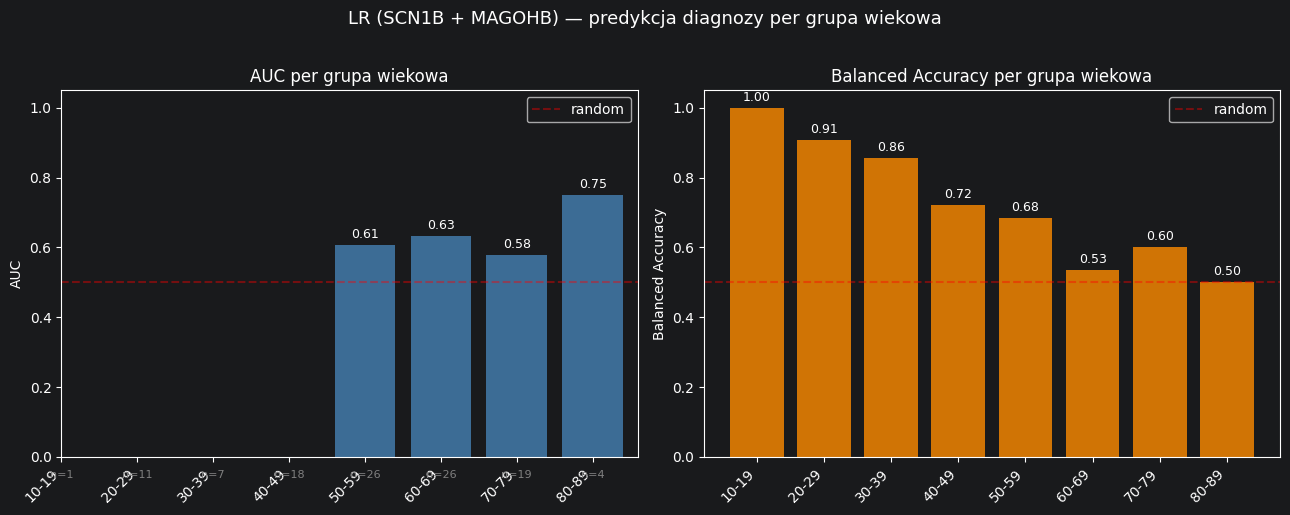

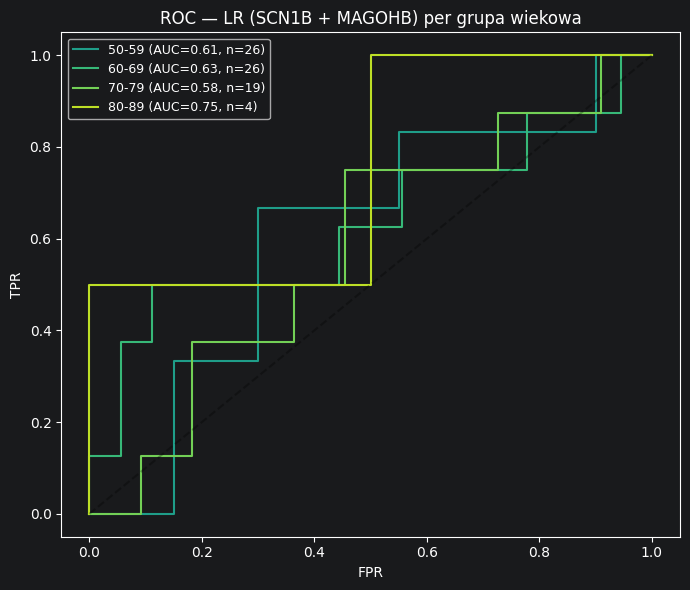

In [4]:
from utilz.constans import MAGOHB, SCN1B
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, roc_curve
from sklearn.linear_model import LogisticRegression

# ── Tylko geny PLA2Sig ──────────────────────────────────────────
X_train_2g = X_train[[SCN1B, MAGOHB]]
X_test_2g  = X_test[[SCN1B, MAGOHB]]

# ── Wiek w test set ─────────────────────────────────────────────
test_age = ds.age.reindex(X_test_2g.index).astype(float)

# ── Trenuj LR na pełnym train ───────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_2g)
X_test_sc  = pd.DataFrame(scaler.transform(X_test_2g), index=X_test_2g.index, columns=X_test_2g.columns)

lr = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=2137)
lr.fit(X_train_sc, y_train)

# ── Grupy wiekowe co 5 lat ──────────────────────────────────────
AGE_BIN_WIDTH = 10
age_min = int(np.floor(test_age.min() / AGE_BIN_WIDTH) * AGE_BIN_WIDTH)
age_max = int(np.ceil(test_age.max() / AGE_BIN_WIDTH) * AGE_BIN_WIDTH)
bins = list(range(age_min, age_max + AGE_BIN_WIDTH, AGE_BIN_WIDTH))
labels = [f"{b}-{b+AGE_BIN_WIDTH-1}" for b in bins[:-1]]
age_groups = pd.cut(test_age, bins=bins, labels=labels, right=False)

# ── Metryki per grupa wiekowa ───────────────────────────────────
results = []
for grp in labels:
    mask = age_groups == grp
    if mask.sum() == 0:
        continue

    idx = X_test_sc.index[mask]
    X_g = X_test_sc.loc[idx]
    y_g = y_test.loc[idx]

    n_total = len(y_g)
    n_cancer = (y_g == 1).sum()
    n_healthy = (y_g == 0).sum()

    y_pred_g = lr.predict(X_g)
    y_proba_g = lr.predict_proba(X_g)[:, 1]

    # AUC wymaga obu klas
    if len(y_g.unique()) >= 2:
        auc = roc_auc_score(y_g, y_proba_g)
    else:
        auc = np.nan

    f1 = f1_score(y_g, y_pred_g, zero_division=0)
    ba = balanced_accuracy_score(y_g, y_pred_g)

    results.append({
        'Grupa wiekowa': grp,
        'n': n_total,
        'n_cancer': n_cancer,
        'n_healthy': n_healthy,
        'AUC': auc,
        'F1': f1,
        'Balanced Acc': ba,
    })

df_results = pd.DataFrame(results)
print("Logistic Regression (SCN1B + MAGOHB) — metryki per grupa wiekowa")
print("=" * 75)
print(df_results.to_string(index=False, float_format="%.3f"))

# ── Wykres: AUC i Balanced Accuracy per grupa ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
x_pos = range(len(df_results))
ax1.bar(x_pos, df_results['AUC'], color='steelblue', alpha=0.8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_results['Grupa wiekowa'], rotation=45, ha='right')
ax1.set_ylabel('AUC')
ax1.set_title('AUC per grupa wiekowa')
ax1.set_ylim(0, 1.05)
ax1.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='random')
for i, row in df_results.iterrows():
    if not np.isnan(row['AUC']):
        ax1.text(i, row['AUC'] + 0.02, f"{row['AUC']:.2f}", ha='center', fontsize=9)
    ax1.text(i, -0.06, f"n={int(row['n'])}", ha='center', fontsize=8, color='gray')
ax1.legend()

ax2 = axes[1]
ax2.bar(x_pos, df_results['Balanced Acc'], color='darkorange', alpha=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(df_results['Grupa wiekowa'], rotation=45, ha='right')
ax2.set_ylabel('Balanced Accuracy')
ax2.set_title('Balanced Accuracy per grupa wiekowa')
ax2.set_ylim(0, 1.05)
ax2.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='random')
for i, row in df_results.iterrows():
    ax2.text(i, row['Balanced Acc'] + 0.02, f"{row['Balanced Acc']:.2f}", ha='center', fontsize=9)
ax2.legend()

plt.suptitle('LR (SCN1B + MAGOHB) — predykcja diagnozy per grupa wiekowa', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── ROC per grupa wiekowa ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(df_results)))

for i, row in df_results.iterrows():
    grp = row['Grupa wiekowa']
    mask = age_groups == grp
    idx = X_test_sc.index[mask]
    y_g = y_test.loc[idx]
    y_proba_g = lr.predict_proba(X_test_sc.loc[idx])[:, 1]

    if len(y_g.unique()) >= 2:
        fpr, tpr, _ = roc_curve(y_g, y_proba_g)
        ax.plot(fpr, tpr, color=colors[i],
                label=f"{grp} (AUC={row['AUC']:.2f}, n={int(row['n'])})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC — LR (SCN1B + MAGOHB) per grupa wiekowa')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [9]:
from utilz.preprocessing_utilz import CovariatesResidualTransformer

X_train = X_train[[SCN1B, MAGOHB]]
X_test  = X_test[[SCN1B, MAGOHB]]
pipeline = Pipeline([
    ('AgeBiasReductor',  CovariatesResidualTransformer(covariate=ds.age)),
    ('scaler', StandardScaler()),
])
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)
lr = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=2137)
lr.fit(X_train_transformed, y_train)

y_pred = lr.predict(X_test_transformed)

y_pred_g = lr.predict(X_test)
y_proba_g = lr.predict_proba(X_test)[:, 1]

# AUC wymaga obu klas
if len(y_g.unique()) >= 2:
    auc = roc_auc_score(y_test, y_proba_g)
else:
    auc = np.nan

f1 = f1_score(y_test, y_pred_g, zero_division=0)
ba = balanced_accuracy_score(y_test, y_pred_g)

print(f1)
print(auc)
print(ba)

data shape after CovariatesResidualTransformer:  (467, 2)
data shape after CovariatesResidualTransformer:  (116, 2)
0.08
0.6997282608695653
0.5208333333333334
